# CLUSTERING ANALYSIS 

###### Understanding and Implementing K-Means and DBSCAN Algorithms

## Data Preprocessing:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')

In [3]:
df.shape

(3999, 12)

In [4]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [6]:
# Remove ID column
if 'ID#' in df.columns:
    df = df.drop(columns=['ID#'])

In [7]:
# Missing values
print(df.isnull().sum())

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [8]:
# Duplicates
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 1


In [9]:
df.duplicated().sum()

np.int64(0)

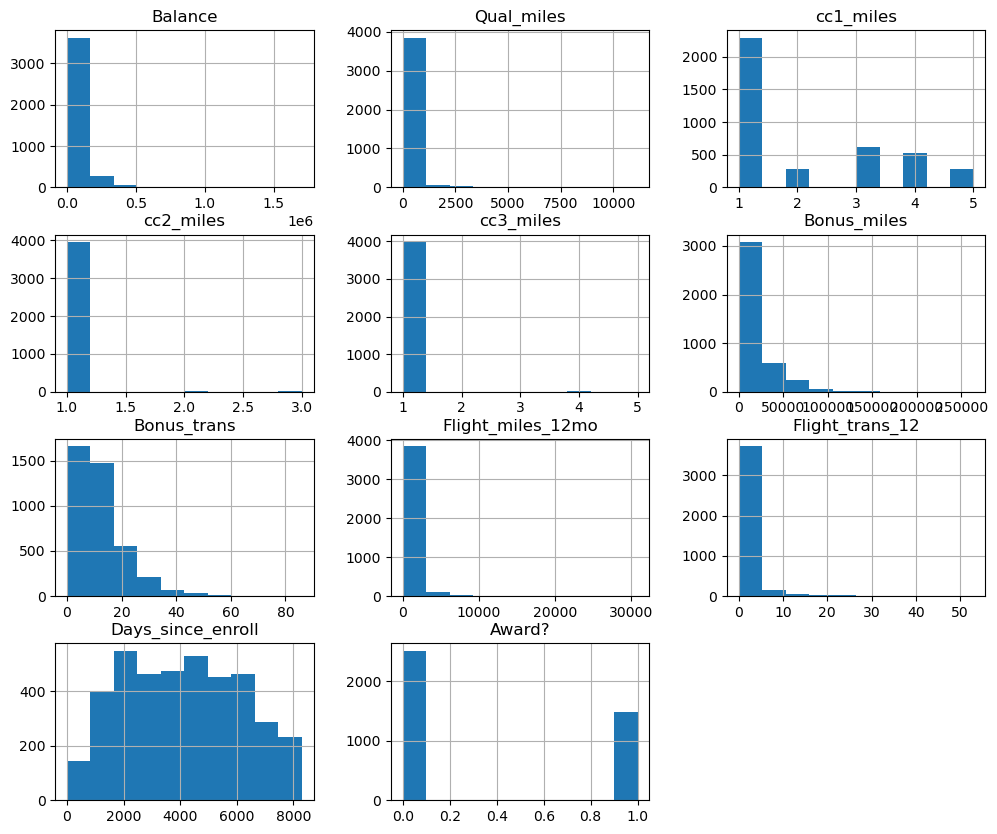

In [10]:
df.hist(figsize=(12,10))
plt.show()

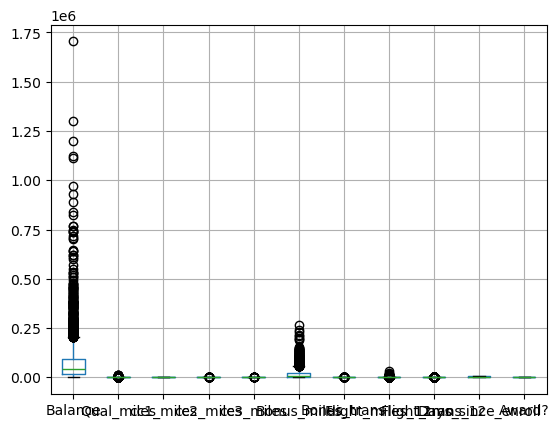

In [11]:
df.boxplot()
plt.show()

In [12]:
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3= df[columns].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[columns]= df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

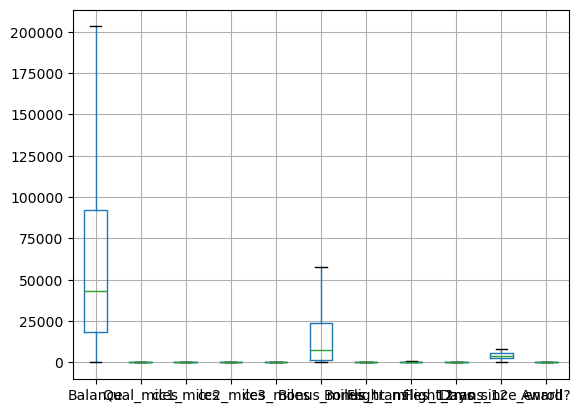

In [13]:
df.boxplot()
plt.show()

### Implementing Clustering Algorithms:

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [15]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

  File "C:\Users\Navya D C\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Navya D C\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Navya D C\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Navya D C\anaconda3

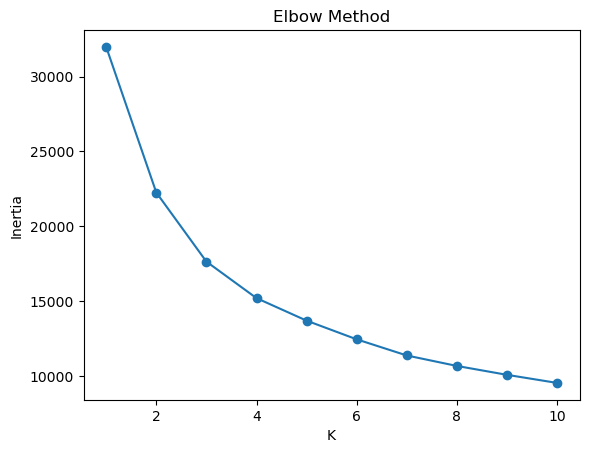

In [16]:
## Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

In [17]:
# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_data)

kmeans_sil = silhouette_score(scaled_data, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_sil)

K-Means Silhouette Score: 0.30689217807618513


In [18]:
# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

print("Clusters:", set(dbscan_labels))

Clusters: {np.int64(0), np.int64(1), np.int64(-1)}


In [19]:
# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

print("Clusters:", set(dbscan_labels))

Clusters: {np.int64(0), np.int64(1), np.int64(-1)}


In [20]:
# K-Means Cluster Analysis
kmeans_df = df.copy()
kmeans_df['Cluster'] = kmeans_labels

kmeans_df.groupby('Cluster').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Cluster,,,,,,,,,,,
0,32736.993165,0.0,1.129863,1.0,1.0,3421.862776,5.962671,15.015247,0.074658,3556.597266,0.149317
1,76129.920381,0.0,1.212318,1.0,1.0,7674.928485,10.507293,650.375608,2.092382,4127.752026,0.513776
2,88696.321545,0.0,3.454545,1.0,1.0,30237.357723,16.744898,26.167904,0.114100,4763.798701,0.517625
3,125075.286160,0.0,4.024938,1.0,1.0,44376.537718,24.927681,642.271820,2.018703,5041.586035,0.802993


In [21]:
# DBSCAN Cluster Analysis
dbscan_df = df.copy()
dbscan_df['Cluster'] = dbscan_labels

dbscan_df.groupby('Cluster').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Cluster,,,,,,,,,,,
-1,127324.590000,0.0,2.800000,1.0,1.0,40043.305000,31.400000,581.080000,1.920000,3713.440000,0.44
0,55627.466540,0.0,1.696364,1.0,1.0,9786.899021,8.992010,109.833999,0.366161,3823.695965,0.00
1,76591.212755,0.0,2.665986,1.0,1.0,24582.983844,15.359864,289.904252,0.953061,4629.234694,1.00


In [ ]:
# PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [ ]:
# K-Means Visualization
plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels)
plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# DBSCAN Visualization
plt.scatter(pca_data[:,0], pca_data[:,1], c=dbscan_labels)
plt.title("DBSCAN Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
#K-Means Silhouette Score
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(scaled_data, kmeans.labels_)
print("K-Means Silhouette Score:", kmeans_score)

In [ ]:
#DBSCAN Silhouette Score
labels = dbscan.labels_

# Remove noise points
mask = labels != -1

if len(set(labels[mask])) > 1:
    dbscan_score = silhouette_score(scaled_data[mask], labels[mask])
    print("DBSCAN Silhouette Score:", dbscan_score)
else:
    print("DBSCAN score cannot be calculated (only one cluster or too much noise).")